In [16]:
import pandas as pd
import matplotlib.pyplot as plt

### read

In [17]:
# Einlesen der gespeicherten CSV-Dateien
merged_data = pd.read_csv("financeData_target_variables.csv", parse_dates=["Date"])

sp500_data = pd.read_csv("temporary_files/sp500_data.csv", parse_dates=["Date"])
tsla_data = pd.read_csv("temporary_files/tsla_data.csv", parse_dates=["Date"])
btc_data = pd.read_csv("temporary_files/btc_data.csv", parse_dates=["Date"])
nasdaq_data = pd.read_csv("temporary_files/nasdaq_data.csv", parse_dates=["Date"])


### add is_trading_day column

In [18]:
# Add isTradingDay column
merged_data["is_trading_day"] = merged_data["sp500_stockprice"].notnull()

### add volatility for S&P500

    DailyVolatility
0               NaN
1               NaN
2               NaN
3               NaN
4               NaN
..              ...
95         0.009792
96         0.009776
97         0.009942
98         0.009951
99         0.009975

[100 rows x 1 columns]


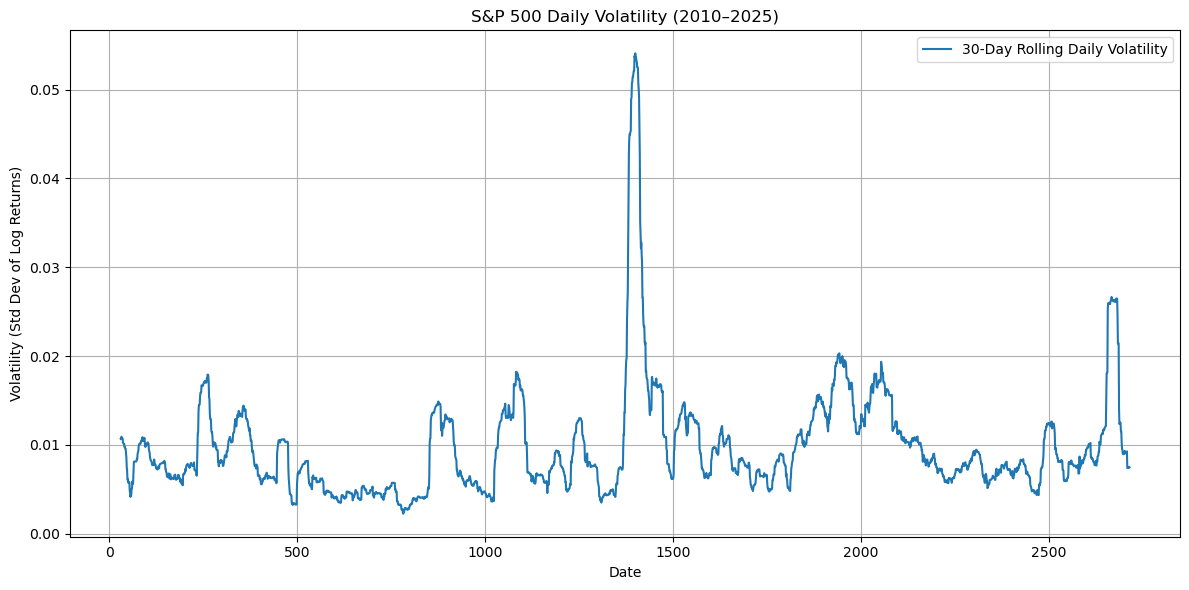

In [19]:
import numpy as np


sp500_data['LogReturn'] = (sp500_data['sp500_stockprice'] / sp500_data['sp500_stockprice'].shift(1)).apply(lambda x: np.log(x))

# 3. Calculate rolling daily volatility (e.g. 30-day window)
# This gives the rolling standard deviation of daily returns
sp500_data['DailyVolatility'] = sp500_data['LogReturn'].rolling(window=30).std()

print(sp500_data[['DailyVolatility']].head(100))

# 4. Plot the daily volatility
plt.figure(figsize=(12,6))
plt.plot(sp500_data.index, sp500_data['DailyVolatility'], label='30-Day Rolling Daily Volatility')
plt.title('S&P 500 Daily Volatility (2010–2025)')
plt.xlabel('Date')
plt.ylabel('Volatility (Std Dev of Log Returns)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### add Volatility for Bitcoin

    DailyVolatility
0               NaN
1               NaN
2               NaN
3               NaN
4               NaN
..              ...
95         0.021728
96         0.022699
97         0.021321
98         0.021483
99         0.021508

[100 rows x 1 columns]


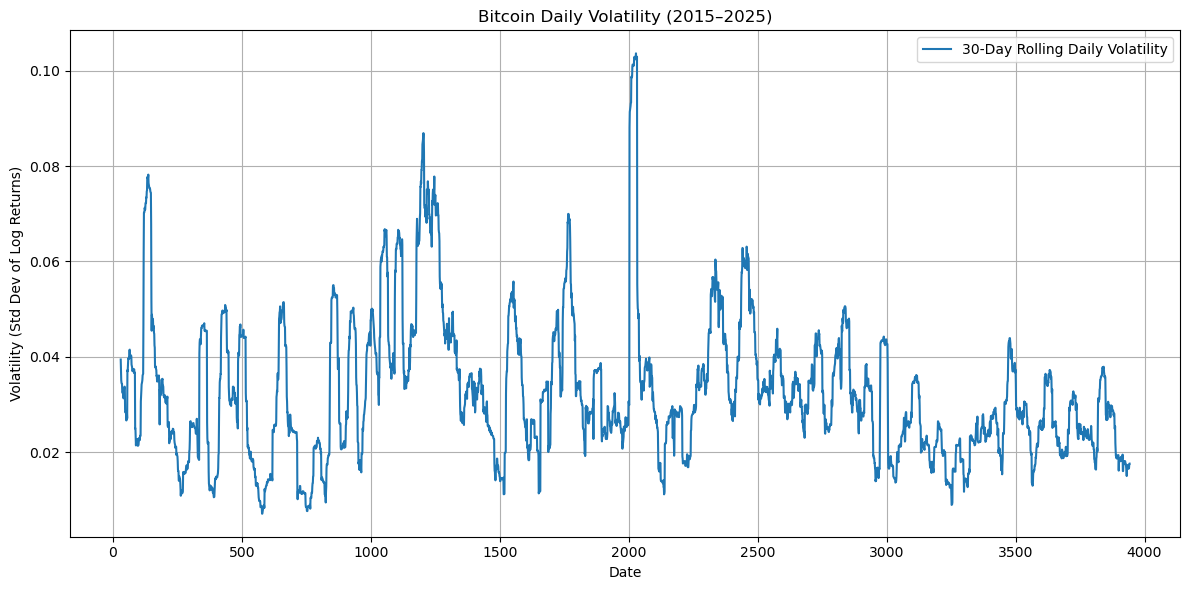

In [20]:
# 2. Calculate daily log returns
btc_data['LogReturn'] = np.log(btc_data['bitcoin_stockprice'] / btc_data['bitcoin_stockprice'].shift(1))

# 3. Calculate rolling daily volatility (e.g. 30-day window)
btc_data['DailyVolatility'] = btc_data['LogReturn'].rolling(window=30).std()

# 4. Inspect first 100 rows
print(btc_data[['DailyVolatility']].head(100))

# 5. Plot the daily volatility
plt.figure(figsize=(12,6))
plt.plot(btc_data.index, btc_data['DailyVolatility'], label='30-Day Rolling Daily Volatility')
plt.title('Bitcoin Daily Volatility (2015–2025)')
plt.xlabel('Date')
plt.ylabel('Volatility (Std Dev of Log Returns)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### add volatility for NASDAQ

    DailyVolatility
0               NaN
1               NaN
2               NaN
3               NaN
4               NaN
..              ...
95         0.009935
96         0.009917
97         0.010083
98         0.010096
99         0.010112

[100 rows x 1 columns]


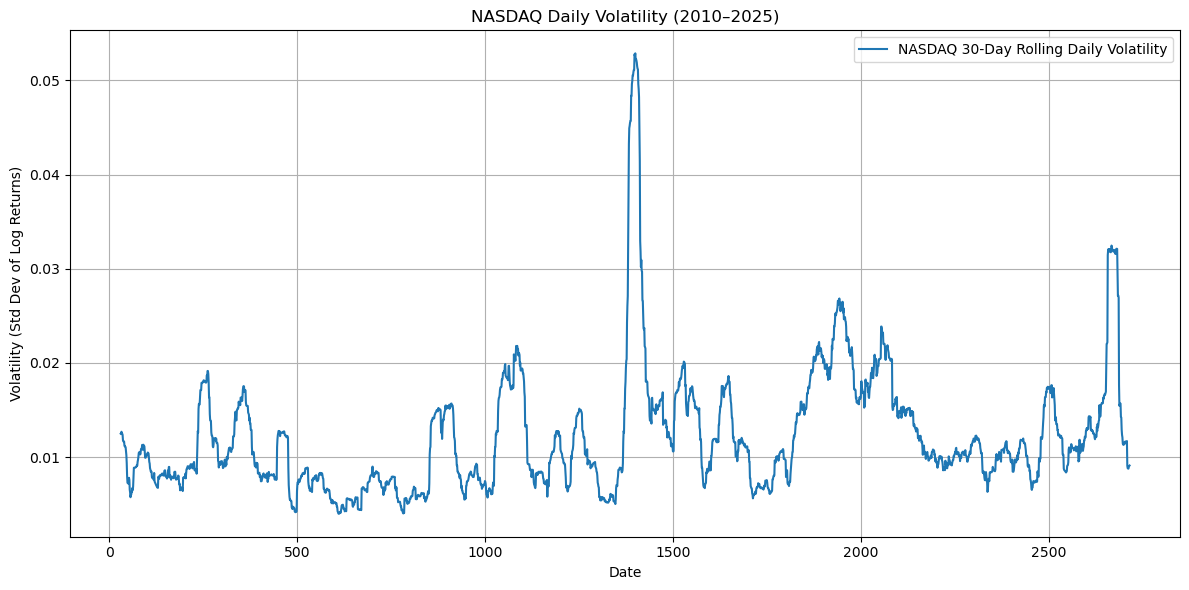

In [21]:
# 2. Calculate daily log returns
nasdaq_data['LogReturn'] = np.log(nasdaq_data['nasdaq_stockprice'] / nasdaq_data['nasdaq_stockprice'].shift(1))

# 3. Calculate rolling daily volatility (e.g. 30-day window)
nasdaq_data['DailyVolatility'] = nasdaq_data['LogReturn'].rolling(window=30).std()

# 4. Print first 100 rows of volatility
print(nasdaq_data[['DailyVolatility']].head(100))

# 5. Plot the daily volatility
plt.figure(figsize=(12,6))
plt.plot(nasdaq_data.index, nasdaq_data['DailyVolatility'], label='NASDAQ 30-Day Rolling Daily Volatility')
plt.title('NASDAQ Daily Volatility (2010–2025)')
plt.xlabel('Date')
plt.ylabel('Volatility (Std Dev of Log Returns)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### add volatiliy for Tesla

    DailyVolatility
0               NaN
1               NaN
2               NaN
3               NaN
4               NaN
..              ...
95         0.022026
96         0.022009
97         0.021928
98         0.022095
99         0.022064

[100 rows x 1 columns]


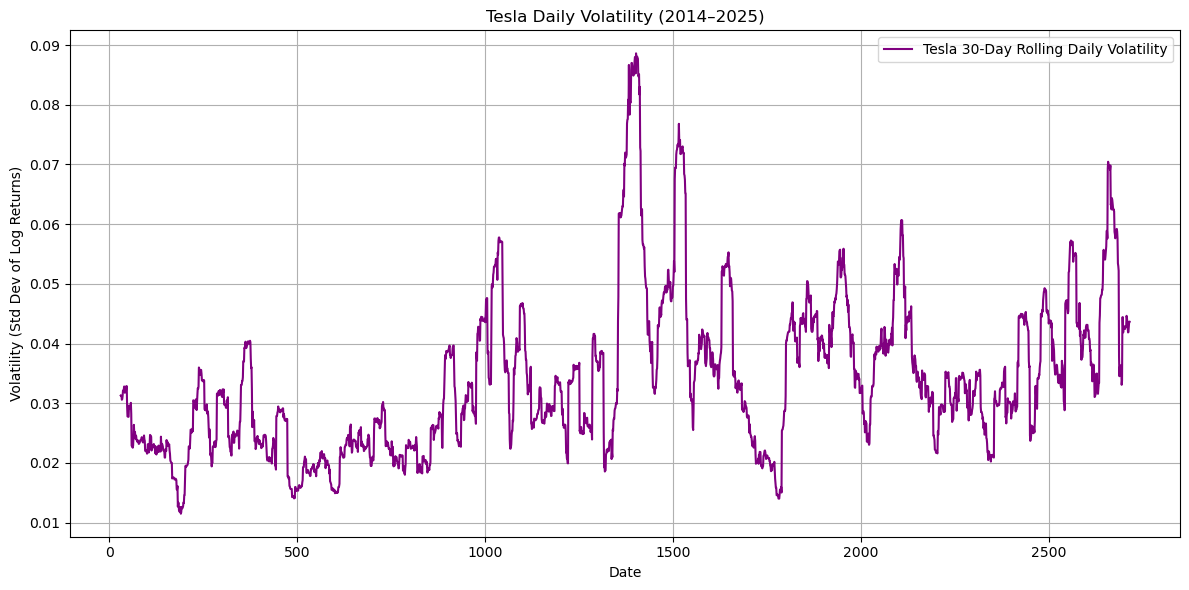

In [22]:
# Calculate daily log returns for Tesla
tsla_data['LogReturn'] = np.log(tsla_data['tesla_stockprice'] / tsla_data['tesla_stockprice'].shift(1))

# Calculate rolling daily volatility (30-day window)
tsla_data['DailyVolatility'] = tsla_data['LogReturn'].rolling(window=30).std()

# Print first 100 rows of volatility
print(tsla_data[['DailyVolatility']].head(100))

# Plot the daily volatility
plt.figure(figsize=(12,6))
plt.plot(tsla_data.index, tsla_data['DailyVolatility'], label='Tesla 30-Day Rolling Daily Volatility', color='purple')
plt.title('Tesla Daily Volatility (2014–2025)')
plt.xlabel('Date')
plt.ylabel('Volatility (Std Dev of Log Returns)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### merge volatility data

In [23]:
# Vorbereitung: sicherstellen, dass alle DataFrames eine 'Date'-Spalte haben
for df in [merged_data, sp500_data, btc_data, nasdaq_data, tsla_data]:
    if 'Date' not in df.columns:
        df.reset_index(inplace=True)
    df['Date'] = pd.to_datetime(df['Date'])

# Merge der Volatility-Daten auf 'Date'
merged_data = merged_data.merge(
    sp500_data[['Date', 'DailyVolatility']],
    on='Date', how='left'
).rename(columns={'DailyVolatility': 'sp500_volatility'})

merged_data = merged_data.merge(
    btc_data[['Date', 'DailyVolatility']],
    on='Date', how='left'
).rename(columns={'DailyVolatility': 'bitcoin_volatility'})

merged_data = merged_data.merge(
    nasdaq_data[['Date', 'DailyVolatility']],
    on='Date', how='left'
).rename(columns={'DailyVolatility': 'nasdaq_volatility'})

merged_data = merged_data.merge(
    tsla_data[['Date', 'DailyVolatility']],
    on='Date', how='left'
).rename(columns={'DailyVolatility': 'tesla_volatility'})

# Sortieren und Index setzen (optional)
merged_data.sort_values('Date', inplace=True)

# Vorschau
print(merged_data.head())


        Date  sp500_stockprice  bitcoin_stockprice  nasdaq_stockprice  \
0 2014-09-17       2001.569946          457.334015        4562.189941   
1 2014-09-18       2011.359985          424.440002        4593.430176   
2 2014-09-19       2010.400024          394.795990        4579.790039   
3 2014-09-20               NaN          408.903992                NaN   
4 2014-09-21               NaN          398.821014                NaN   

   tesla_stockprice  sp500_volume  bitcoin_volume  nasdaq_volume  \
0         17.425333  3.209420e+09        21056800   1.796710e+09   
1         17.587999  3.235340e+09        34483200   1.774840e+09   
2         17.288000  4.880220e+09        37919700   3.178490e+09   
3               NaN           NaN        36863600            NaN   
4               NaN           NaN        26580100            NaN   

   tesla_volume  is_trading_day  sp500_volatility  bitcoin_volatility  \
0    77665500.0            True               NaN                 NaN   
1    5

In [24]:
volatility_cols = [
    'sp500_volatility', 'bitcoin_volatility',
    'nasdaq_volatility', 'tesla_volatility'
]

merged_data.ffill(inplace=True)  # wirkt auf alle Spalten
merged_data[volatility_cols] = merged_data[volatility_cols].fillna(0)

print(merged_data)


           Date  sp500_stockprice  bitcoin_stockprice  nasdaq_stockprice  \
0    2014-09-17       2001.569946          457.334015        4562.189941   
1    2014-09-18       2011.359985          424.440002        4593.430176   
2    2014-09-19       2010.400024          394.795990        4579.790039   
3    2014-09-20       2010.400024          408.903992        4579.790039   
4    2014-09-21       2010.400024          398.821014        4579.790039   
...         ...               ...                 ...                ...   
3938 2025-06-29       6173.069824       108385.570312       20273.460938   
3939 2025-06-30       6204.950195       107135.335938       20369.730469   
3940 2025-07-01       6198.009766       105698.281250       20202.890625   
3941 2025-07-02       6227.419922       108859.320312       20393.130859   
3942 2025-07-03       6279.350098       109647.976562       20601.099609   

      tesla_stockprice  sp500_volume  bitcoin_volume  nasdaq_volume  \
0            17.

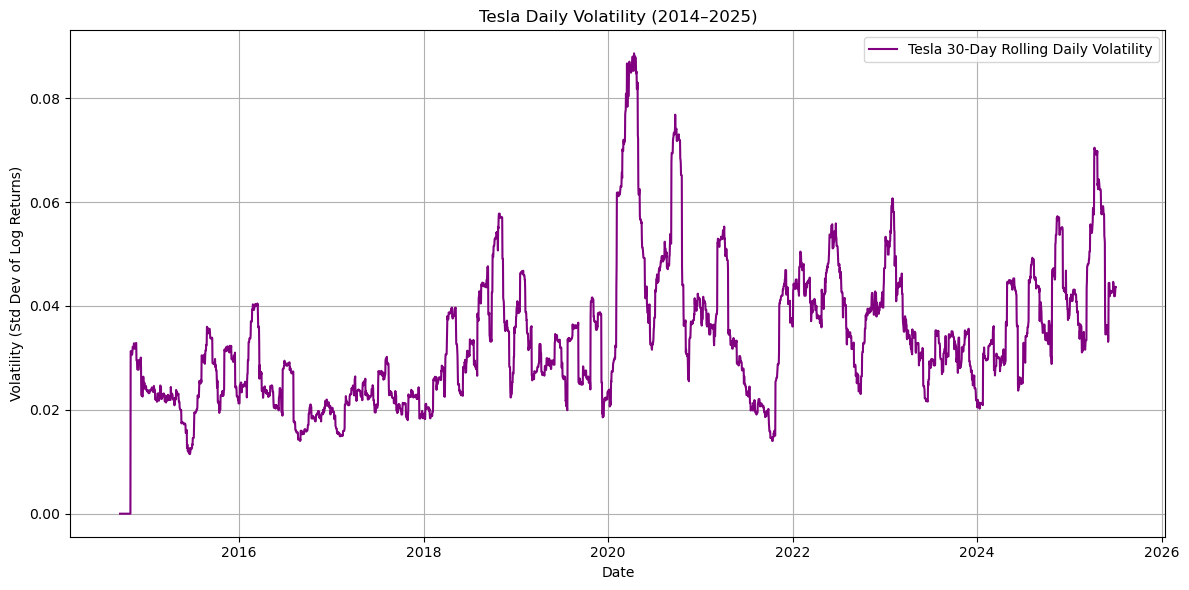

In [25]:
#debug
plt.figure(figsize=(12,6))
plt.plot(merged_data['Date'], merged_data['tesla_volatility'], label='Tesla 30-Day Rolling Daily Volatility', color='purple')
plt.title('Tesla Daily Volatility (2014–2025)')
plt.xlabel('Date')
plt.ylabel('Volatility (Std Dev of Log Returns)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Add high and low values

In [26]:
# --- Rename columns for clarity ---
sp500_data = sp500_data.rename(columns={'High': 'sp500_high', 'Low': 'sp500_low'})
btc_data = btc_data.rename(columns={'High': 'bitcoin_high', 'Low': 'bitcoin_low'})
nasdaq_data = nasdaq_data.rename(columns={'High': 'nasdaq_high', 'Low': 'nasdaq_low'})
tsla_data = tsla_data.rename(columns={'High': 'tesla_high', 'Low': 'tesla_low'})

# --- Sicherstellen, dass alle DataFrames eine 'Date'-Spalte haben ---
for df in [merged_data, sp500_data, btc_data, nasdaq_data, tsla_data]:
    if 'Date' not in df.columns:
        df.reset_index(inplace=True)
    df['Date'] = pd.to_datetime(df['Date'])

# --- Merge High/Low columns auf Date ---
merged_data = merged_data.merge(
    sp500_data[['Date', 'sp500_high', 'sp500_low']],
    on='Date', how='left'
).merge(
    btc_data[['Date', 'bitcoin_high', 'bitcoin_low']],
    on='Date', how='left'
).merge(
    nasdaq_data[['Date', 'nasdaq_high', 'nasdaq_low']],
    on='Date', how='left'
).merge(
    tsla_data[['Date', 'tesla_high', 'tesla_low']],
    on='Date', how='left'
)

# --- Wieder sortieren und ggf. Index setzen ---
merged_data.sort_values('Date', inplace=True)

# --- Vorschau ---
print(merged_data[[
    'sp500_high', 'sp500_low',
    'bitcoin_high', 'bitcoin_low',
    'nasdaq_high', 'nasdaq_low',
    'tesla_high', 'tesla_low'
]].head())


    sp500_high    sp500_low  bitcoin_high  bitcoin_low  nasdaq_high  \
0  2010.739990  1993.290039    468.174011   452.421997  4582.399902   
1  2012.339966  2003.069946    456.859985   413.104004  4593.979980   
2  2019.260010  2006.589966    427.834991   384.532013  4610.569824   
3          NaN          NaN    423.295990   389.882996          NaN   
4          NaN          NaN    412.425995   393.181000          NaN   

    nasdaq_low  tesla_high  tesla_low  
0  4539.359863   17.646667  17.299999  
1  4572.620117   17.706667  17.488001  
2  4563.439941   17.428667  17.018000  
3          NaN         NaN        NaN  
4          NaN         NaN        NaN  


### add daily percentual change

In [27]:
# --- Stockprice: %-Change berechnen unter neuem Namen ---
merged_data["bitcoin_change_stockprice"] = (
    merged_data["bitcoin_stockprice"]
      .div(merged_data["bitcoin_stockprice"].shift(1))
      .subtract(1)
      .mul(100)
)
merged_data["sp500_change_stockprice"] = (
    merged_data["sp500_stockprice"]
      .div(merged_data["sp500_stockprice"].shift(1))
      .subtract(1)
      .mul(100)
)
merged_data["nasdaq_change_stockprice"] = (
    merged_data["nasdaq_stockprice"]
      .div(merged_data["nasdaq_stockprice"].shift(1))
      .subtract(1)
      .mul(100)
)
merged_data["tesla_change_stockprice"] = (
    merged_data["tesla_stockprice"]
      .div(merged_data["tesla_stockprice"].shift(1))
      .subtract(1)
      .mul(100)
)

# --- Volume: %-Change berechnen ---
merged_data["bitcoin_change_volume"] = (
    merged_data["bitcoin_volume"]
      .div(merged_data["bitcoin_volume"].shift(1))
      .subtract(1)
      .mul(100)
)
merged_data["sp500_change_volume"] = (
    merged_data["sp500_volume"]
      .div(merged_data["sp500_volume"].shift(1))
      .subtract(1)
      .mul(100)
)
merged_data["nasdaq_change_volume"] = (
    merged_data["nasdaq_volume"]
      .div(merged_data["nasdaq_volume"].shift(1))
      .subtract(1)
      .mul(100)
)
merged_data["tesla_change_volume"] = (
    merged_data["tesla_volume"]
      .div(merged_data["tesla_volume"].shift(1))
      .subtract(1)
      .mul(100)
)

# --- change_volatility ---

# Schutz gegen Division durch 0 oder NaN
def safe_pct_change(series):
    prev = series.shift(1)
    pct_change = np.where(
        (prev == 0) | (prev.isna()),
        np.nan,
        (series / prev - 1) * 100
    )
    return pd.Series(pct_change, index=series.index)

merged_data["bitcoin_change_volatility"] = safe_pct_change(merged_data["bitcoin_volatility"])
merged_data["sp500_change_volatility"] = safe_pct_change(merged_data["sp500_volatility"])
merged_data["nasdaq_change_volatility"] = safe_pct_change(merged_data["nasdaq_volatility"])
merged_data["tesla_change_volatility"] = safe_pct_change(merged_data["tesla_volatility"])


# --- Erste Zeile in allen Change-Spalten auf 0 setzen ---
all_change_cols = [
    "bitcoin_change_stockprice", "sp500_change_stockprice", "nasdaq_change_stockprice", "tesla_change_stockprice",
    "bitcoin_change_volume",     "sp500_change_volume",     "nasdaq_change_volume",     "tesla_change_volume",
    "bitcoin_change_volatility", "sp500_change_volatility", "nasdaq_change_volatility", "tesla_change_volatility"
]
merged_data.loc[merged_data.index[0], all_change_cols] = 0


### output everything as csv

In [28]:
# Save all datasets to CSV files
print(merged_data.head())
merged_data.to_csv("financeData_target_variables.csv", index=False)

        Date  sp500_stockprice  bitcoin_stockprice  nasdaq_stockprice  \
0 2014-09-17       2001.569946          457.334015        4562.189941   
1 2014-09-18       2011.359985          424.440002        4593.430176   
2 2014-09-19       2010.400024          394.795990        4579.790039   
3 2014-09-20       2010.400024          408.903992        4579.790039   
4 2014-09-21       2010.400024          398.821014        4579.790039   

   tesla_stockprice  sp500_volume  bitcoin_volume  nasdaq_volume  \
0         17.425333  3.209420e+09        21056800   1.796710e+09   
1         17.587999  3.235340e+09        34483200   1.774840e+09   
2         17.288000  4.880220e+09        37919700   3.178490e+09   
3         17.288000  4.880220e+09        36863600   3.178490e+09   
4         17.288000  4.880220e+09        26580100   3.178490e+09   

   tesla_volume  is_trading_day  ...  nasdaq_change_stockprice  \
0    77665500.0            True  ...                  0.000000   
1    55389000.0     

In [29]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3943 entries, 0 to 3942
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       3943 non-null   datetime64[ns]
 1   sp500_stockprice           3943 non-null   float64       
 2   bitcoin_stockprice         3943 non-null   float64       
 3   nasdaq_stockprice          3943 non-null   float64       
 4   tesla_stockprice           3943 non-null   float64       
 5   sp500_volume               3943 non-null   float64       
 6   bitcoin_volume             3943 non-null   int64         
 7   nasdaq_volume              3943 non-null   float64       
 8   tesla_volume               3943 non-null   float64       
 9   is_trading_day             3943 non-null   bool          
 10  sp500_volatility           3943 non-null   float64       
 11  bitcoin_volatility         3943 non-null   float64       
 12  nasdaq

In [30]:
#debug
import pandas as pd

# --- CSV einlesen ---
df = pd.read_csv("temporary_files/nasdaq_data.csv", parse_dates=["Date"])
df.set_index("Date", inplace=True)
df.sort_index(inplace=True)

# --- Vollständigen Börsenkalender (nur Werktage) erzeugen ---
full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq="B")

# --- Fehlende Tage berechnen ---
missing_dates = full_index.difference(df.index)

# --- Ausgabe mit Wochentagen ---
missing_df = pd.DataFrame(missing_dates, columns=["MissingDate"])
missing_df["Weekday"] = missing_df["MissingDate"].dt.day_name()

# --- Ergebnisse anzeigen ---
print(f"Anzahl fehlender Börsentage: {len(missing_df)}")
print(missing_df)

# --- Optional: Nur nicht-Wochenenden anzeigen ---
non_weekends = missing_df[~missing_df["Weekday"].isin(["Saturday", "Sunday"])]
print("\n❗ Fehlende Tage außerhalb des Wochenendes:")
print(non_weekends)


Anzahl fehlender Börsentage: 102
    MissingDate   Weekday
0    2014-11-27  Thursday
1    2014-12-25  Thursday
2    2015-01-01  Thursday
3    2015-01-19    Monday
4    2015-02-16    Monday
..          ...       ...
97   2025-01-20    Monday
98   2025-02-17    Monday
99   2025-04-18    Friday
100  2025-05-26    Monday
101  2025-06-19  Thursday

[102 rows x 2 columns]

❗ Fehlende Tage außerhalb des Wochenendes:
    MissingDate   Weekday
0    2014-11-27  Thursday
1    2014-12-25  Thursday
2    2015-01-01  Thursday
3    2015-01-19    Monday
4    2015-02-16    Monday
..          ...       ...
97   2025-01-20    Monday
98   2025-02-17    Monday
99   2025-04-18    Friday
100  2025-05-26    Monday
101  2025-06-19  Thursday

[102 rows x 2 columns]
